In [1]:
import pandas as pd
import string
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("C:/Users/bohar/Desktop/fake_review (1)/fake reviews dataset.csv")

df.head()


,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


In [3]:
# check original columns
print("Before rename:", df.columns)

# remove extra spaces (VERY IMPORTANT)
df.columns = df.columns.str.strip()

# rename safely
if 'text_' in df.columns:
    df = df.rename(columns={"text_": "review"})
elif 'text' in df.columns:
    df = df.rename(columns={"text": "review"})

# check again
print("After rename:", df.columns)

# convert label
df['label'] = df['label'].apply(lambda x: "genuine" if x == "CG" else "fake")

# keep only needed columns
df = df[['review', 'label']]

df.head()

Before rename: Index(['category', 'rating', 'label', 'text_'], dtype='object')
After rename: Index(['category', 'rating', 'label', 'review'], dtype='object')


,review,label
0,"Love this! Well made, sturdy, and very comfor...",genuine
1,"love it, a great upgrade from the original. I...",genuine
2,This pillow saved my back. I love the look and...,genuine
3,"Missing information on how to use it, but it i...",genuine
4,Very nice set. Good quality. We have had the s...,genuine


In [4]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

df['review'] = df['review'].apply(clean_text)

# extra feature (optional but good for viva)
df['length'] = df['review'].apply(len)

df.head()

,review,label,length
0,love this well made sturdy and very comfortabl...,genuine,69
1,love it a great upgrade from the original i ve...,genuine,77
2,this pillow saved my back i love the look and ...,genuine,66
3,missing information on how to use it but it is...,genuine,78
4,very nice set good quality we have had the set...,genuine,83


In [5]:
from sklearn.model_selection import train_test_split

X = df['review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("\nReport:\n", classification_report(y_test, lr_pred, zero_division=0))

Logistic Regression Accuracy: 0.8601459131940151

Report:
               precision    recall  f1-score   support

        fake       0.85      0.87      0.86      4071
     genuine       0.87      0.85      0.86      4016

    accuracy                           0.86      8087
   macro avg       0.86      0.86      0.86      8087
weighted avg       0.86      0.86      0.86      8087



In [8]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy: 0.8436997650550266


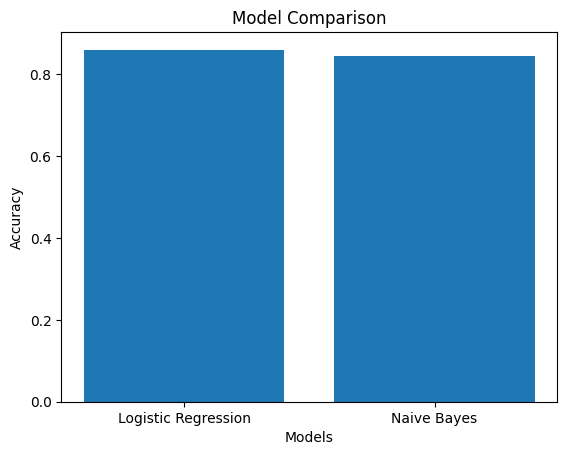

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

models = ["Logistic Regression", "Naive Bayes"]

acc_lr = accuracy_score(y_test, lr_pred)
acc_nb = accuracy_score(y_test, nb_pred)

accuracies = [acc_lr, acc_nb]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

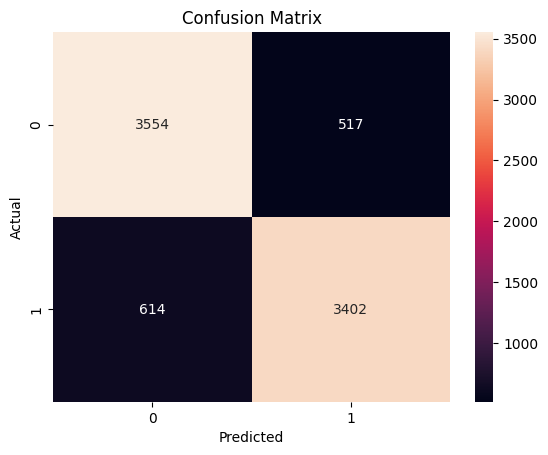

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, lr_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
user_input = input("Enter review: ")

clean = clean_text(user_input)
vec = tfidf.transform([clean])

print("Prediction:", lr_model.predict(vec)[0])

Enter review:  This is the best product ever!!! Everyone must buy this right now, totally life-changing!!!


Prediction: fake


In [23]:
import pickle

model = pickle.load(open("model.pkl", "rb"))
vectorizer = pickle.load(open("vectorizer.pkl", "rb"))

text = input("Enter review: ")
vec = vectorizer.transform([text])

print("Prediction:", model.predict(vec)[0])

Enter review:  good


Prediction: genuine
